# PCA Dimensionality Reduction and Animated K-Means++ Clustering

This notebook demonstrates:
1. Extracting and profiling a 4-dimensional dataset.
2. Dimensionality reduction via PCA to 2D for visualization.
3. K-Means clustering using the K-Means++ initialization algorithm with full iteration tracing.
4. Generating a high-quality GIF that visualizes centroid movement and point assignments.

**Dataset**: Fisher's Iris dataset provided by `sklearn.datasets`. The dataset contains four numerical features and three species labels.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Minimal Exploratory Data Analysis (EDA)

Load the Iris dataset and inspect its shape and feature names.

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
true_labels = iris.target
target_names = iris.target_names
print(f"Dataset Shape: {df.shape} (Rows: {df.shape[0]}, Features: {df.shape[1]})")
print(f"Numerical Features: {list(df.columns)}")
print(df.head().to_string())

Dataset Shape: (150, 4) (Rows: 150, Features: 4)
Numerical Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


## 2. Dimensionality Reduction via PCA

Standardize features and apply PCA to reduce the four-dimensional data to two principal components for visualization and clustering.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Original Shape: {X_scaled.shape} -> PCA Output Shape: {X_pca.shape}")
print(f"Explained Variance Ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total Variance Captured: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original Shape: (150, 4) -> PCA Output Shape: (150, 2)
Explained Variance Ratio (PC1, PC2): [0.72962445 0.22850762]
Total Variance Captured: 95.81%


## 3. Step-by-Step K-Means with K-Means++ Initialization

We implement the K-Means++ centroid seeding strategy and then run iterative K-Means, storing centroid positions and assignments at each step for animation.

In [4]:
def kmeans_pp_init(X, k, random_state=42):
    n_samples = X.shape[0]
    rng = np.random.RandomState(random_state)
    centroids = np.empty((k, X.shape[1]))
    first_idx = rng.randint(n_samples)
    centroids[0] = X[first_idx]
    distances = np.linalg.norm(X - centroids[0], axis=1) ** 2
    for i in range(1, k):
        probs = distances / distances.sum()
        r = rng.rand()
        cumprobs = probs.cumsum()
        idx = np.searchsorted(cumprobs, r)
        centroids[i] = X[idx]
        new_dist = np.linalg.norm(X - centroids[i], axis=1) ** 2
        distances = np.minimum(distances, new_dist)
    return centroids
k = 3
centroids = kmeans_pp_init(X_pca, k, random_state=RANDOM_STATE)
history_centroids = [centroids.copy()]
history_labels = []
converged = False
iteration = 0
while not converged and iteration < 50:
    distances = np.linalg.norm(X_pca[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    history_labels.append(labels.copy())
    new_centroids = np.array([X_pca[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i] for i in range(k)])
    history_centroids.append(new_centroids.copy())
    if np.allclose(centroids, new_centroids, atol=1e-9):
        converged = True
    centroids = new_centroids
    iteration += 1
print(f"K-Means++ converged after {iteration} iterations.")
print(f"Tracked {len(history_labels)} state updates for animation.")

K-Means++ converged after 6 iterations.
Tracked 6 state updates for animation.


## 3.5 Model Evaluation (Accuracy and Confusion Matrix)

Map each cluster to the most frequent true species inside it and compute a simple mapped accuracy and confusion matrix.

K-Means++ Mapped Accuracy to True Species: 85.33%



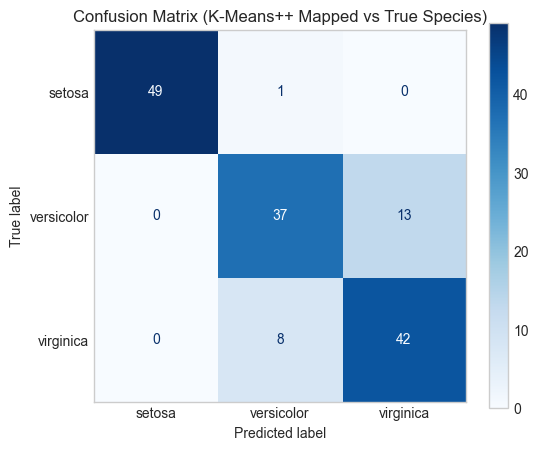

In [5]:
final_labels = history_labels[-1]
mapped_labels = np.zeros_like(final_labels)
cluster_to_species = {}
for i in range(k):
    mask = (final_labels == i)
    if np.any(mask):
        most_common = np.bincount(true_labels[mask]).argmax()
        mapped_labels[mask] = most_common
        cluster_to_species[i] = target_names[most_common]
    else:
        cluster_to_species[i] = f"Cluster {i}"
accuracy = accuracy_score(true_labels, mapped_labels)
print(f"K-Means++ Mapped Accuracy to True Species: {accuracy * 100:.2f}%\n")
cm = confusion_matrix(true_labels, mapped_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax_cm = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax_cm)
plt.title("Confusion Matrix (K-Means++ Mapped vs True Species)")
plt.grid(False)
plt.show()

## 4. Animating Iterations (GIF Output)

Create an animation showing point assignments, centroid movements, and a Voronoi-style background to emphasize cluster regions. The GIF will be saved into the repository `animations` folder.

In [6]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
ax.set_title("K-Means++ Clustering Iterations", fontsize=16, fontweight='bold', pad=20)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
dark_colors = ['#0f3b5a', '#803f07', '#165016']
light_cmap = ListedColormap(['#c6dff2', '#ffdabd', '#b8f2c6'])
true_species_to_color_idx = {}
available_indices = [0, 1, 2]
for k_idx, sp_name in cluster_to_species.items():
    if sp_name not in true_species_to_color_idx and sp_name in target_names:
        true_species_to_color_idx[sp_name] = k_idx
        available_indices.remove(k_idx)
for sp_name in target_names:
    if sp_name not in true_species_to_color_idx:
        true_species_to_color_idx[sp_name] = available_indices.pop(0)
true_point_colors = [colors[true_species_to_color_idx[target_names[lbl]]] for lbl in true_labels]
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
mesh_points = np.c_[xx.ravel(), yy.ravel()]
scatter_points = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=true_point_colors, s=45, alpha=0.9, edgecolors='k', zorder=5)
scatter_cents = ax.scatter(history_centroids[0][:, 0], history_centroids[0][:, 1], c=dark_colors, marker='X', s=250, edgecolors='white', linewidths=2, zorder=15)
legend_patches = [Patch(facecolor=colors[i], edgecolor=dark_colors[i], label=cluster_to_species[i]) for i in range(k)]
ax.legend(handles=legend_patches, title="Species Mapping", loc='upper left', frameon=True, facecolor='white', framealpha=0.9).set_zorder(20)
title_text = ax.text(0.5, 0.98, '', transform=ax.transAxes, ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', zorder=20))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6, zorder=1)
arrows = []
spider_lines = []
state = {'contour': None}
def clear_contour():
    if state['contour']:
        try:
            state['contour'].remove()
        except AttributeError:
            for coll in state['contour'].collections:
                try:
                    coll.remove()
                except Exception:
                    pass
        state['contour'] = None
def clear_spider_lines():
    while spider_lines:
        ln = spider_lines.pop()
        ln.remove()
def init():
    scatter_cents.set_offsets(history_centroids[0])
    title_text.set_text('')
    clear_contour()
    clear_spider_lines()
    return scatter_points, scatter_cents, title_text
def animate(i):
    frame_idx = min(i, len(history_labels) - 1)
    curr_cents = history_centroids[frame_idx]
    labels = history_labels[frame_idx]
    clear_contour()
    dist_mesh = np.linalg.norm(mesh_points[:, np.newaxis] - curr_cents, axis=2)
    mesh_labels = np.argmin(dist_mesh, axis=1).reshape(xx.shape)
    state['contour'] = ax.contourf(xx, yy, mesh_labels, alpha=0.4, cmap=light_cmap, vmin=0, vmax=k-1, zorder=0)
    clear_spider_lines()
    for c_idx in range(k):
        cluster_mask = (labels == c_idx)
        cluster_pts = X_pca[cluster_mask]
        cent_pt = curr_cents[c_idx]
        for pt in cluster_pts:
            ln, = ax.plot([cent_pt[0], pt[0]], [cent_pt[1], pt[1]], color=dark_colors[c_idx], linewidth=0.6, alpha=0.35, zorder=4)
            spider_lines.append(ln)
    scatter_cents.set_offsets(curr_cents)
    while arrows:
        arr = arrows.pop()
        arr.remove()
    if frame_idx > 0:
        prev_cents = history_centroids[frame_idx - 1]
        for p_cent, c_cent in zip(prev_cents, curr_cents):
            arr = ax.annotate('', xy=c_cent, xytext=p_cent, arrowprops=dict(arrowstyle="->", color='#333333', lw=2, alpha=0.8, shrinkA=0, shrinkB=0), zorder=10)
            arrows.append(arr)
    title_text.set_text(f"Iteration: {frame_idx + 1} / {len(history_labels)}")
    return []
total_frames = len(history_labels) + 2
anim = FuncAnimation(fig, animate, init_func=init, frames=total_frames, interval=1500, blit=False)
gif_path = os.path.abspath(os.path.join('animations', 'kmeans_pp_animation.gif'))
os.makedirs(os.path.dirname(gif_path), exist_ok=True)
anim.save(gif_path, dpi=120, writer=PillowWriter(fps=0.7))
plt.close(fig)
print(f"Successfully saved K-Means++ animation to: {gif_path}")

Successfully saved K-Means++ animation to: d:\Git-Projects\clustering-algorithms\notebooks\animations\kmeans_pp_animation.gif
